# Chladni02

The program computes one solution for a vibrating square plate by solving 
the corresponding stationary partial differential equation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigsh

## Parameters

In [2]:
a   = 10.0          # Edge length in cm
rho = 9.5e-4        # Density in kg/cm^3
mu  = 10.0          # Torsion modulus in N/dm^2

## Create solution object and define geometry

In [3]:
# Grid for square domain [-a/2, a/2] x [-a/2, a/2]
N = 400  # grid resolution
x = np.linspace(-a/2, a/2, N)
y = np.linspace(-a/2, a/2, N)
X, Y = np.meshgrid(x, y)

h = x[1] - x[0]

# All grid points are inside the square
mask = np.ones_like(X, dtype=bool)

# Flatten indexing
indices = np.arange(N*N)
interior_indices = indices  # full square domain
num_points = len(interior_indices)

# Mapping global → reduced system
id_map = np.arange(N*N).reshape(N*N)

## Solve the PDE

We solve the eigenvalue problem for a vibrating square plate:

$$
\mu \nabla^2 u + \lambda \rho u = 0
\quad \Rightarrow \quad
-\nabla^2 u = \frac{\rho}{\mu} \lambda u
$$

Dirichlet boundary condition:
$$
u = 0 \text{ on the boundary}
$$

In the numerical implementation, the Laplacian operator is approximated 
using a finite difference scheme, resulting in a discrete eigenvalue problem:

$$
L u = k u
$$

where $L \approx -\nabla^2$ and $k = \frac{\rho}{\mu}\lambda$.

In [4]:
# Solving the partial differential equation

# Identify interior points (exclude boundary)
interior_mask = np.ones((N, N), dtype=bool)
interior_mask[0, :] = False
interior_mask[-1, :] = False
interior_mask[:, 0] = False
interior_mask[:, -1] = False

interior_indices = np.where(interior_mask.flatten())[0]
num_interior = len(interior_indices)

# Mapping global → reduced system
id_map = -np.ones(N*N, dtype=int)
id_map[interior_indices] = np.arange(num_interior)

# Build Laplacian
A = lil_matrix((num_interior, num_interior))

for idx in interior_indices:
    i, j = divmod(idx, N)
    row = id_map[idx]
    
    A[row, row] = -4 / h**2
    
    for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
        ni, nj = i + di, j + dj
        neighbor_idx = ni * N + nj
        
        if id_map[neighbor_idx] != -1:
            A[row, id_map[neighbor_idx]] = 1 / h**2
        # else: boundary → u=0 → nothing to add

# Operator
L = -A

# Solve eigenproblem
k_vals, u_vecs = eigsh(L, k=6, which='SM')

eigenvalues = k_vals * mu / rho

## Visualization

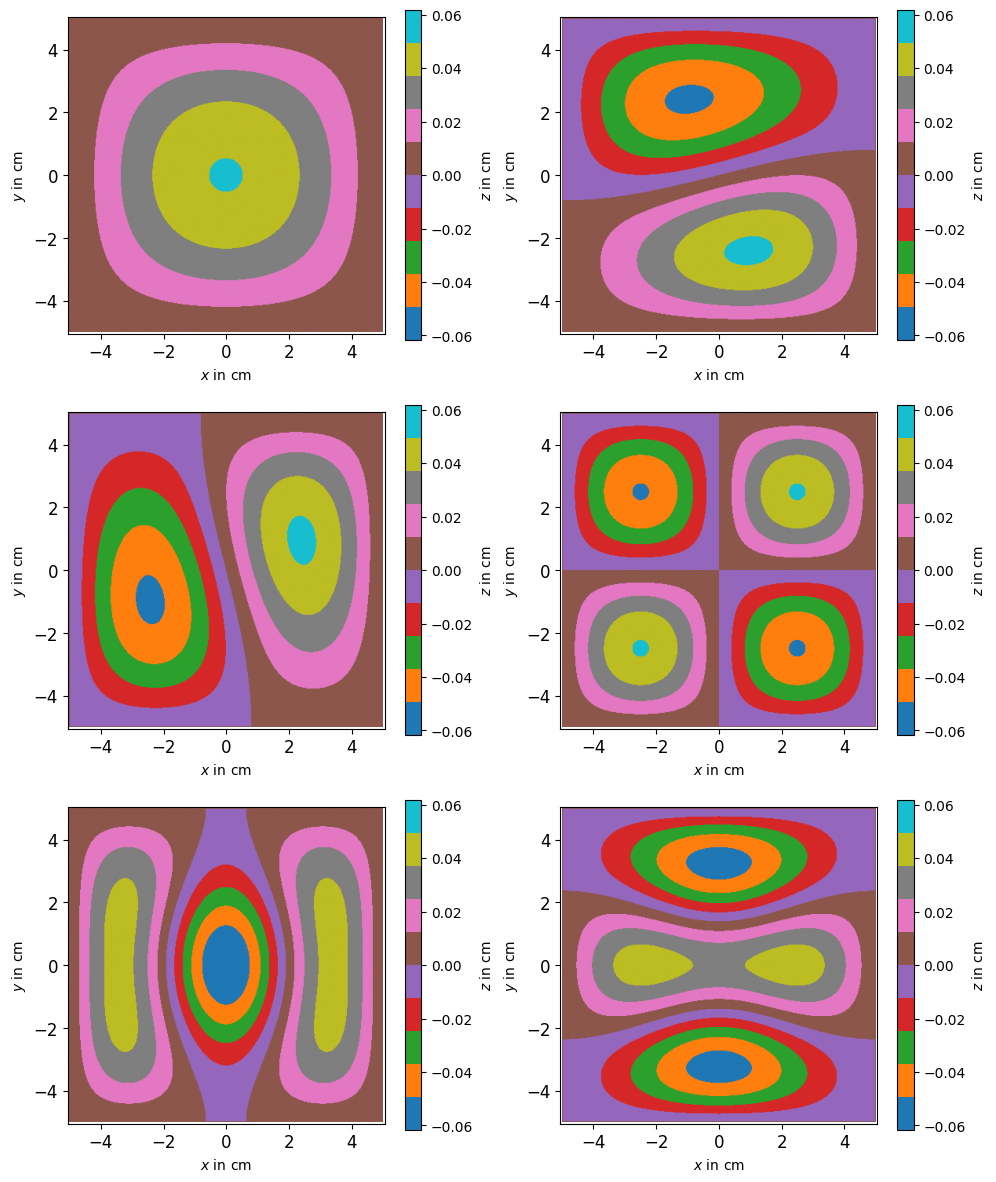

In [5]:
# Reshape eigenvectors to grid
# Reconstruct full grid
full = np.zeros((N*N, 6))
full[interior_indices, :] = u_vecs

modes = full.reshape((N, N, 6))

cmap = plt.get_cmap('tab10')

scale = 10.0

global_max = np.max(np.abs(modes)) * scale
vmin = -global_max
vmax = global_max

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.ravel()

# extent for imshow: [xmin, xmax, ymin, ymax]
extent = [x.min(), x.max(), y.min(), y.max()]

for i in range(6):
    ax = axes[i]
    
    U = modes[:, :, i] * scale
    # mask outside disk for nicer plotting
    U_masked = np.ma.array(U, mask=~mask)
    im = ax.imshow(U_masked, origin='lower', extent=extent, cmap=cmap, norm=norm)

    ax.set_aspect('equal')
    ax.set_xlim([-0.505*a, 0.505*a])
    ax.set_ylim([-0.505*a, 0.505*a])
    
    ax.set_xlabel('$\\it{x}$ in cm')
    ax.set_ylabel('$\\it{y}$ in cm')
    
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('$\\it{z}$ in cm')
    
    ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

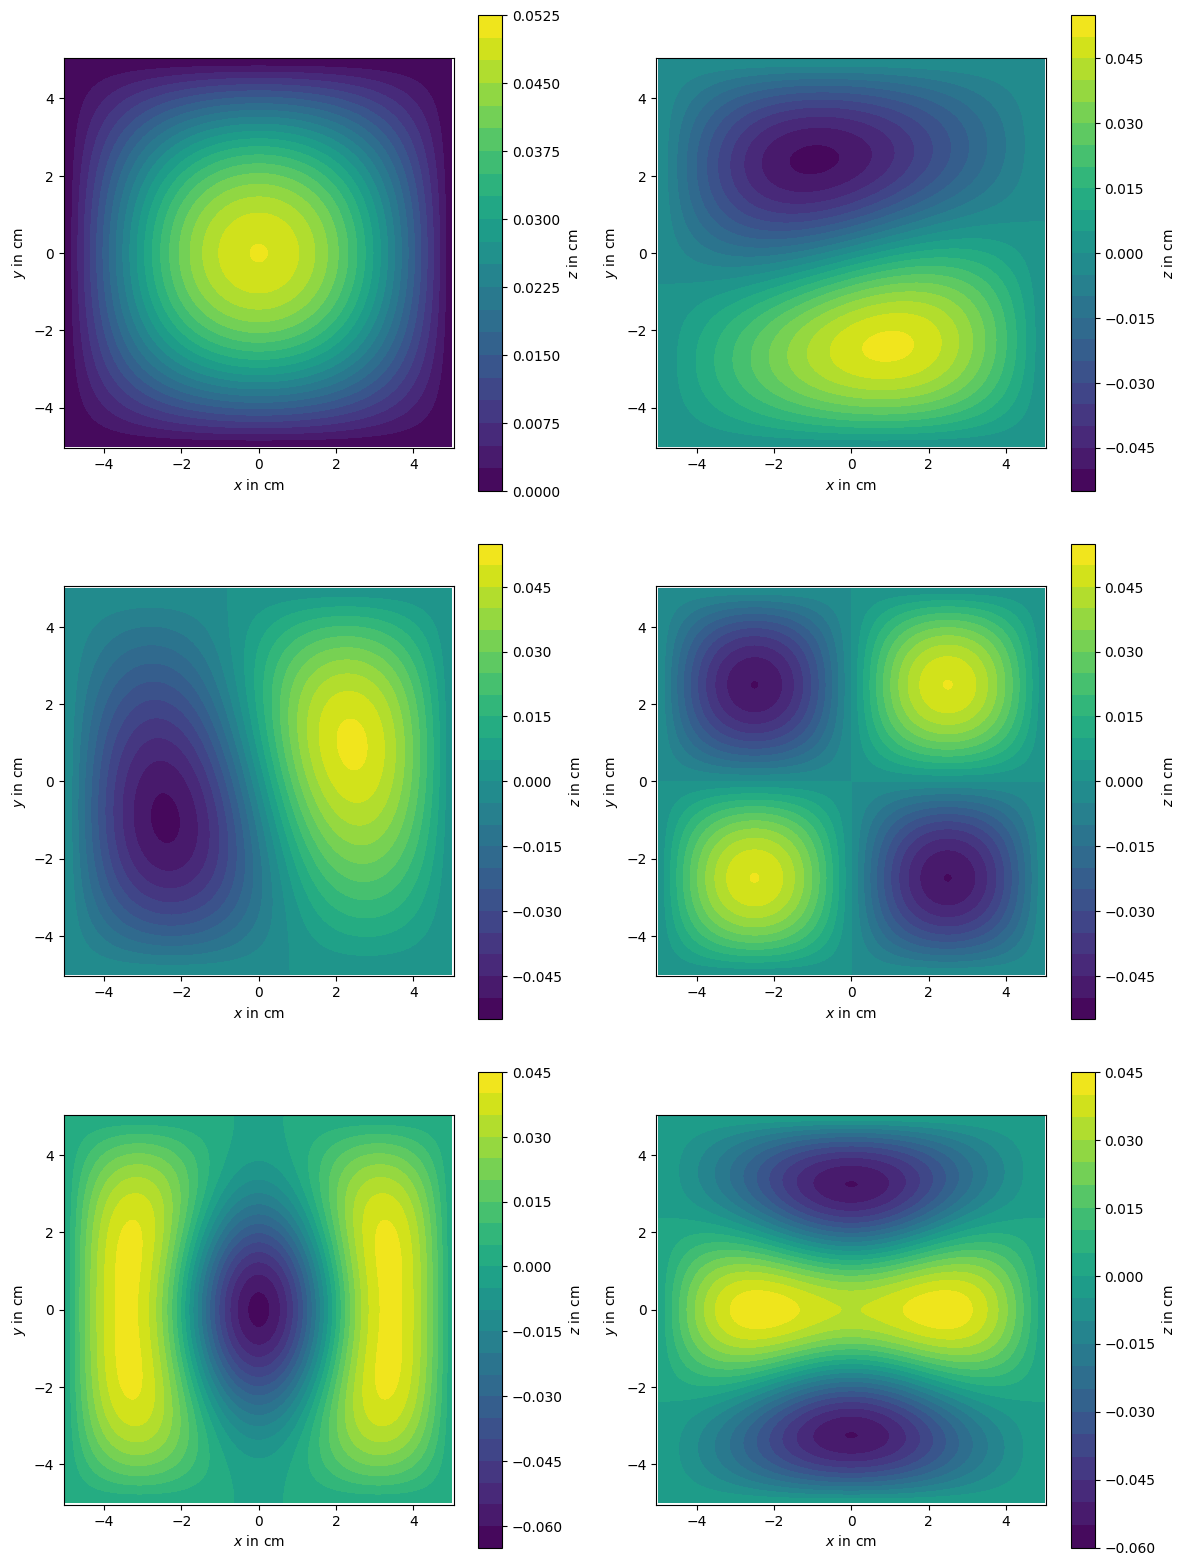

In [6]:
# Visualization without change color
fig = plt.figure(figsize=(12, 16))

for i in range(6):
    ax = fig.add_subplot(3, 2, i+1)
    
    # Reconstruct full grid
    u_grid = np.zeros(N*N)
    u_grid[interior_indices] = u_vecs[:, i]
    U = u_grid.reshape((N, N))
    
    # Contour plot (similar to MATLAB pdeplot)
    cont = ax.contourf(X, Y, U * 10, levels=20, cmap='viridis')
    
    ax.set_aspect('equal')
    ax.set_xlim([-0.505*a, 0.505*a])
    ax.set_ylim([-0.505*a, 0.505*a])
    
    ax.set_xlabel("$\\mathit{x}$ in cm")
    ax.set_ylabel("$\\mathit{y}$ in cm")
    
    cbar = fig.colorbar(cont, ax=ax)
    cbar.set_label("$\\mathit{z}$ in cm")
    
plt.tight_layout()
plt.show()